## Made by Бутер Бродский aka Nyamerka)

### Воропаев Иван, М8О-309Б-22

In [28]:
# Импортируем тонны библиотек
import os
import optuna
from optuna.samplers import TPESampler
from boruta import BorutaPy
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
import category_encoders as ce

Для начала нужно считать данные:

In [29]:
loan_data = pd.read_csv('train.csv')

Отлично. Теперь у нас есть данные - начинаем обработку.

In [30]:
loan_data.head()
info = loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

In [31]:
loan_data.describe()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,UtilityBillsPaymentHistory,JobTenure,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,10487.000000,10487.000000,9986.000000,9986.000000,10487.000000,10487.000000,9986.000000,10487.000000,10487.000000,10487.000000,...,10487.000000,10487.000000,10487.000000,9.986000e+03,9986.000000,10487.000000,10487.000000,10487.000000,10487.000000,1.048700e+04
mean,39.850386,131587.872127,678.082716,29874.218306,53.439878,1.568323,546.458642,0.284397,3.033565,0.979498,...,0.784428,4.949271,17.628302,1.542381e+05,0.200392,0.200112,1075.622426,0.517577,0.511776,-2.569878e+04
std,11.614132,115791.941909,175.192486,27705.509722,24.493562,1.418684,501.981888,0.159240,1.740186,0.990927,...,0.123039,2.201100,11.337248,4.622229e+05,0.094388,0.096458,1344.053181,0.894637,0.499885,1.431675e+06
min,18.000000,15000.000000,300.000000,1063.000000,12.000000,0.000000,13.000000,0.003674,0.000000,0.000000,...,0.259301,0.000000,0.000000,1.004000e+03,0.052494,0.046445,30.008506,0.006064,0.000000,-9.999999e+06
25%,32.000000,20959.500000,550.000000,12658.000000,36.000000,0.000000,233.250000,0.158929,2.000000,0.000000,...,0.708475,3.000000,9.000000,7.252500e+03,0.119908,0.119548,375.872620,0.066734,0.000000,3.256475e+01
50%,40.000000,89015.000000,722.500000,21828.500000,48.000000,1.000000,398.000000,0.262229,3.000000,1.000000,...,0.803692,5.000000,17.000000,2.742950e+04,0.182023,0.180710,684.878529,0.178193,1.000000,4.411876e+01
75%,48.000000,257025.000000,850.000000,37158.000000,60.000000,3.000000,685.000000,0.391683,4.000000,2.000000,...,0.879312,6.000000,26.000000,1.241758e+05,0.264709,0.264880,1279.930203,0.637457,1.000000,6.535690e+01
max,80.000000,748508.000000,850.000000,418997.000000,120.000000,6.000000,10879.000000,0.914635,12.000000,6.000000,...,0.996573,17.000000,57.000000,1.126117e+07,0.722497,0.833647,29634.807816,24.383046,1.000000,1.000000e+07


In [32]:
loan_data.isnull().sum()

ApplicationDate                530
Age                            530
AnnualIncome                   530
CreditScore                   1031
LoanAmount                    1031
LoanDuration                   530
MaritalStatus                  530
NumberOfDependents             530
HomeOwnershipStatus            530
MonthlyDebtPayments           1031
CreditCardUtilizationRate      530
NumberOfOpenCreditLines        530
NumberOfCreditInquiries        530
DebtToIncomeRatio              530
BankruptcyHistory             1031
LoanPurpose                   1031
PreviousLoanDefaults           530
PaymentHistory                 530
LengthOfCreditHistory          530
SavingsAccountBalance          530
CheckingAccountBalance        1031
TotalAssets                   1031
TotalLiabilities               530
MonthlyIncome                  530
UtilityBillsPaymentHistory     530
JobTenure                      530
EmploymentStatus               530
EducationLevel                 530
Experience          

In [33]:
loan_data.duplicated().sum()

1016

In [34]:
print(loan_data.nunique(), loan_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

In [35]:
loan_data = loan_data.dropna()
loan_data = loan_data.loc[(loan_data['RiskScore'] >= 0) & (loan_data['RiskScore'] <= 100)]
loan_data.drop_duplicates(inplace=True)
print(loan_data['RiskScore'].min(), loan_data['RiskScore'].max())
print(set(loan_data['LoanApproved'])) # Должны быть только значения 0 и 1 - то есть да или нет.

14.841417296887238 97.59724939432462
{0.0, 1.0}


По идее, на данном этапе должна начаться предобработка признаков. Однако у нас есть некоторый выбор алгоритма бустинга. По идее, это либо XGBoost, либо CatBoost. Однако у них есть принципиальное отличие.

+ CatBoost - поддерживает обработку категорий. То есть предобработка не нужна.
+ XGBoost - не поддерживает категории, то есть они уже должны быть обработаны.
+ LightBoost - также без категорий, но быстро.

В общем, используем Cat

Дату нужно будет распарсить в любом случае)

In [36]:
loan_data['ApplicationDate'] = pd.to_datetime(loan_data['ApplicationDate'])

loan_data['ApplicationYear'] = loan_data['ApplicationDate'].dt.year
loan_data['ApplicationMonth'] = loan_data['ApplicationDate'].dt.month
loan_data['ApplicationDay'] = loan_data['ApplicationDate'].dt.day

loan_data = loan_data.drop(columns=['ApplicationDate'])

Разбиваем сет на части

In [37]:
categorical_columns = ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose','EmploymentStatus', 'EducationLevel', 'ApplicationYear', 'ApplicationMonth', 'ApplicationDay']

target = 'LoanApproved'

numerical_columns = loan_data.drop(columns=categorical_columns + [target]).columns

print(numerical_columns)

if len(numerical_columns) + len(categorical_columns) + len([target]) != len(loan_data.columns):
    raise ValueError('Количество колонок не совпадает')

Index(['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration',
       'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'Experience', 'NetWorth', 'BaseInterestRate',
       'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio',
       'RiskScore'],
      dtype='object')


Строим графики

In [38]:
# from matplotlib import pyplot as plt
#
# loan_data.hist(color='Green', bins=20, figsize=(25,30))
# plt.suptitle('Распределения данных по каждому столбцу', fontsize=20)
# plt.show()

Добавляем HeatMap

In [39]:
# import seaborn as sns
#
# plt.figure(figsize=(30, 20))
# plt.title('Корреляция численных данных')
# loan_data.corr(numeric_only=True)
# sns.heatmap(loan_data.corr(numeric_only=True), annot=True, fmt=".2f")

Создаём новые фичи. Квадтары каждой численной метрики и перемноженные друг на друга признаки.

In [40]:
def create_new_features(loan_data, numerical_columns, degree=2):
    for col1, col2 in combinations(numerical_columns, 2):
        new_col_name = f"{col1}_x_{col2}"
        loan_data[new_col_name] = loan_data[col1] * loan_data[col2]

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly_features = poly.fit_transform(loan_data[numerical_columns])

    poly_feature_names = poly.get_feature_names_out(numerical_columns)

    poly_df = pd.DataFrame(poly_features, columns=poly_feature_names, index=loan_data.index)
    loan_data = pd.concat([loan_data, poly_df], axis=1)

    loan_data = loan_data.loc[:, ~loan_data.columns.duplicated()]
    return loan_data

print(numerical_columns)

loan_data = create_new_features(loan_data, numerical_columns)

print(f"Размер данных после генерации новых признаков: {loan_data.shape}")

Index(['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration',
       'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'Experience', 'NetWorth', 'BaseInterestRate',
       'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio',
       'RiskScore'],
      dtype='object')


/var/folders/vw/cndmvq5n1bb8z2gt5w41m8l80000gn/T/ipykernel_68412/2325787575.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  loan_data[new_col_name] = loan_data[col1] * loan_data[col2]
/var/folders/vw/cndmvq5n1bb8z2gt5w41m8l80000gn/T/ipykernel_68412/2325787575.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  loan_data[new_col_name] = loan_data[col1] * loan_data[col2]
/var/folders/vw/cndmvq5n1bb8z2gt5w41m8l80000gn/T/ipykernel_68412/2325787575.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

Размер данных после генерации новых признаков: (9332, 879)


Получили 879 признаков. Нужно обновить наши колонки, так как появились новые.

In [41]:
# Пересчитываем списки колонок
def update_columns(loan_data, target, predefined_categorical):
    # Все категориальные данные, которые остались неизменными
    categorical_columns = [col for col in predefined_categorical if col in loan_data.columns]

    # Числовые колонки определяем как все оставшиеся, кроме целевой переменной и категориальных
    numerical_columns = list(set(loan_data.columns) - set(categorical_columns) - set([target]))

    return numerical_columns, categorical_columns

# Обновляем списки колонок
numerical_columns, categorical_columns = update_columns(loan_data, target, categorical_columns)

# Проверка корректности
if len(numerical_columns) + len(categorical_columns) + 1 != len(loan_data.columns):
    raise ValueError('Количество колонок не совпадает')

# Выводим размеры и актуальные списки
print(f"Размер данных: {loan_data.shape}")
print(f"Числовые колонки: {numerical_columns}")
print(f"Категориальные колонки: {categorical_columns}")

Размер данных: (9332, 879)
Числовые колонки: ['NumberOfDependents MonthlyIncome', 'NumberOfDependents TotalDebtToIncomeRatio', 'NumberOfOpenCreditLines InterestRate', 'BankruptcyHistory TotalDebtToIncomeRatio', 'Age RiskScore', 'MonthlyIncome InterestRate', 'InterestRate_x_TotalDebtToIncomeRatio', 'LoanDuration BankruptcyHistory', 'CheckingAccountBalance_x_TotalAssets', 'JobTenure TotalDebtToIncomeRatio', 'UtilityBillsPaymentHistory RiskScore', 'TotalLiabilities_x_BaseInterestRate', 'Age DebtToIncomeRatio', 'AnnualIncome NetWorth', 'AnnualIncome CheckingAccountBalance', 'Age_x_UtilityBillsPaymentHistory', 'LoanAmount MonthlyLoanPayment', 'PaymentHistory^2', 'LoanAmount MonthlyDebtPayments', 'CheckingAccountBalance RiskScore', 'DebtToIncomeRatio PreviousLoanDefaults', 'Age MonthlyLoanPayment', 'CreditScore TotalLiabilities', 'PreviousLoanDefaults RiskScore', 'PaymentHistory NetWorth', 'NumberOfDependents BaseInterestRate', 'TotalAssets MonthlyIncome', 'TotalAssets NetWorth', 'DebtToInco

Кодируем данные енкодером из CatBoosting.

In [42]:
# Обновляем списки колонок после добавления новых фичей
def encode_categorical_features(loan_data, categorical_columns, target):
    if not categorical_columns:
        print("Категориальные признаки отсутствуют. Пропускаем обработку.")
        return loan_data

    # Инициализация TargetEncoder
    encoder = ce.TargetEncoder(cols=categorical_columns)

    # Преобразуем данные
    loan_data[categorical_columns] = encoder.fit_transform(loan_data[categorical_columns], loan_data[target])

    return loan_data

# Применяем обработку категориальных признаков
loan_data = encode_categorical_features(loan_data, categorical_columns, target)

# Проверяем и преобразуем оставшиеся object-столбцы
for col in categorical_columns:
    if loan_data[col].dtype == 'object' or loan_data[col].dtype == 'category':
        print(f"Преобразуем колонку {col} из object в числовой формат.")
        # Посмотрим на уникальные значения
        print(f"Уникальные значения в колонке {col}:", loan_data[col].unique())

        # Преобразуем в числовой формат, заменяя некорректные значения на NaN
        loan_data[col] = pd.to_numeric(loan_data[col], errors='coerce')

        # Если остались NaN, заполним их средним значением
        if loan_data[col].isna().sum() > 0:
            print(f"Найдены NaN в колонке {col}, заполняем средним значением.")
            loan_data[col] = loan_data[col].fillna(loan_data[col].mean())

# Принудительное преобразование колонок в float
columns_to_convert = ['UtilityBillsPaymentHistory', 'TotalDebtToIncomeRatio']

for col in columns_to_convert:
    print(f"Преобразуем колонку {col} в float.")
    loan_data[col] = pd.to_numeric(loan_data[col], errors='coerce')

# Проверяем, что преобразование прошло успешно
unsupported_types = loan_data.select_dtypes(include=['object']).columns.tolist()
if unsupported_types:
    raise ValueError(f"После преобразования остаются неподдерживаемые типы: {unsupported_types}")

# Проверка результата
print(f"Размер данных после обработки категорий: {loan_data.shape}")

unsupported_types = loan_data.select_dtypes(include=['object']).columns.tolist()
if unsupported_types:
    raise ValueError(f"Обнаружены неподдерживаемые типы: {unsupported_types}")

if len(numerical_columns) + len(categorical_columns) + 1 != len(loan_data.columns):
    raise ValueError('Количество колонок не совпадает')

Преобразуем колонку UtilityBillsPaymentHistory в float.
Преобразуем колонку TotalDebtToIncomeRatio в float.
Размер данных после обработки категорий: (9332, 879)


Выбираем, какой Scaler лучше всего использовать.

In [43]:
loan_data[categorical_columns] = loan_data[categorical_columns].astype(str)

# Функция для выбора и применения скейлера
def normalize_and_evaluate(trial, loan_data, numerical_columns, target):
    # Выбор скейлера
    scaler_name = trial.suggest_categorical('scaler', ['StandardScaler', 'MinMaxScaler', 'RobustScaler', 'MaxAbsScaler'])

    if scaler_name == 'StandardScaler':
        scaler = StandardScaler()
    elif scaler_name == 'MinMaxScaler':
        scaler = MinMaxScaler()
    elif scaler_name == 'RobustScaler':
        scaler = RobustScaler()
    elif scaler_name == 'MaxAbsScaler':
        scaler = MaxAbsScaler()
    else:
        raise ValueError("Unknown scaler selected.")

    # Применение скейлера только к числовым данным
    loan_data[numerical_columns] = scaler.fit_transform(loan_data[numerical_columns])

    # Разделение данных
    X = loan_data.drop(columns=[target])
    y = loan_data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Обучение модели
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    # Оценка модели
    y_pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    trial.set_user_attr("scaler", scaler)  # Сохраняем скейлер в атрибутах
    return auc

# Функция оптимизации скейлера
def optimize_scaler(loan_data, numerical_columns, categorical_columns, target, n_trials=20):
    def objective(trial):
        return normalize_and_evaluate(trial, loan_data.copy(), numerical_columns, target)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    # Сохранение лучшего скейлера
    best_trial = study.best_trial
    best_scaler = best_trial.user_attrs["scaler"]
    return best_scaler

# Оптимизация скейлера
best_scaler = optimize_scaler(loan_data, numerical_columns, categorical_columns, target, n_trials=20)

# Применение лучшего скейлера к числовым данным
loan_data[numerical_columns] = best_scaler.fit_transform(loan_data[numerical_columns])

print(best_scaler)

# Проверка итогового размера данных
print(f"Размер данных после нормализации: {loan_data.shape}")

[I 2025-01-09 19:35:17,303] A new study created in memory with name: no-name-77aca43c-dec6-49b7-b502-e94a5c9685ef
[I 2025-01-09 19:35:22,284] Trial 0 finished with value: 0.9999162259924351 and parameters: {'scaler': 'MinMaxScaler'}. Best is trial 0 with value: 0.9999162259924351.
/Users/Nyamerka/PycharmProjects/ML_MAI/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[I 2025-01-09 19:35:34,672] Trial 1 finished with value: 0.9577779001872867 and parameters: {'scaler': 'RobustScaler'}. Best is trial 0 with value: 0.9999162259924351.
/Users

MaxAbsScaler()
Размер данных после нормализации: (9332, 879)


Начинаем отбор признаков с помощью Boruta.

In [44]:
features_file = "selected_features.txt"

if os.path.exists(features_file):
    print("Файл с отобранными признаками найден. Загружаем признаки...")
    # Читаем признаки из файла
    with open(features_file, "r") as f:
        selected_features = f.read().splitlines()
    print("Загруженные признаки:", selected_features)
else:
    print("Файл с отобранными признаками не найден. Запускаем Boruta...")
    # Данные для Boruta
    X_class = loan_data.drop(columns=target)
    y_class = loan_data[target]

    # Оценка с использованием ROC AUC
    scorer = make_scorer(roc_auc_score, needs_proba=True)

    # Random Forest для Boruta
    rf = RandomForestClassifier(n_estimators=300, random_state=42)

    # Boruta
    boruta = BorutaPy(estimator=rf, n_estimators='auto', random_state=42)
    boruta.fit(X_class.values, y_class.values)

    # Список выбранных признаков
    selected_features = X_class.columns[boruta.support_].tolist()
    print("Выбранные признаки Boruta:", selected_features)

    # Сохраняем признаки в файл
    with open(features_file, "w") as f:
        f.write("\n".join(selected_features))
    print("Признаки сохранены в файл.")

# Выбранные признаки можно использовать для дальнейшего анализа
print(f"Итоговый список признаков: {selected_features}")

Файл с отобранными признаками найден. Загружаем признаки...
Загруженные признаки: ['AnnualIncome', 'CreditScore', 'LoanAmount', 'PaymentHistory', 'TotalAssets', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore', 'Age_x_AnnualIncome', 'Age_x_LoanAmount', 'Age_x_TotalAssets', 'Age_x_MonthlyIncome', 'Age_x_NetWorth', 'Age_x_BaseInterestRate', 'Age_x_TotalDebtToIncomeRatio', 'Age_x_RiskScore', 'AnnualIncome_x_CreditScore', 'AnnualIncome_x_LoanAmount', 'AnnualIncome_x_LoanDuration', 'AnnualIncome_x_MonthlyDebtPayments', 'AnnualIncome_x_CreditCardUtilizationRate', 'AnnualIncome_x_NumberOfOpenCreditLines', 'AnnualIncome_x_DebtToIncomeRatio', 'AnnualIncome_x_PaymentHistory', 'AnnualIncome_x_LengthOfCreditHistory', 'AnnualIncome_x_TotalAssets', 'AnnualIncome_x_MonthlyIncome', 'AnnualIncome_x_UtilityBillsPaymentHistory', 'AnnualIncome_x_JobTenure', 'AnnualIncome_x_Experience', 'AnnualIncome_x

In [45]:
# print(selected_features)

Обучаем бустинг с помощью Optuna и выводим результат.

In [46]:
# Фильтрация признаков
X_class_selected = loan_data[selected_features]
y_class = loan_data[target]

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X_class_selected, y_class, test_size=0.4, random_state=42)

In [47]:
models = []

In [48]:
# Оптимизация Logistic Regression
def objective_logistic(trial):
    params = {
        "C": trial.suggest_float("C", 1e-4, 10, log=True),
        "solver": trial.suggest_categorical("solver", ["liblinear", "lbfgs"]),
        "random_state": 42
    }
    model = LogisticRegression(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    return np.mean(scores)

study = optuna.create_study(direction="maximize", sampler=TPESampler())
study.optimize(objective_logistic, n_trials=50)
models.append(LogisticRegression(**study.best_params, random_state=42))

[I 2025-01-09 19:36:23,849] A new study created in memory with name: no-name-a7778d59-cc6c-4850-aac8-18d0a942cc1f
[I 2025-01-09 19:36:28,352] Trial 0 finished with value: 0.9850430576238083 and parameters: {'C': 0.2633160138290989, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.9850430576238083.
[I 2025-01-09 19:36:29,196] Trial 1 finished with value: 0.9494854006625799 and parameters: {'C': 0.016416582704112743, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.9850430576238083.
[I 2025-01-09 19:36:29,962] Trial 2 finished with value: 0.949315782962558 and parameters: {'C': 0.02674090508927476, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9850430576238083.
[I 2025-01-09 19:36:30,574] Trial 3 finished with value: 0.9113682873278588 and parameters: {'C': 0.0025361326676907534, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9850430576238083.
[I 2025-01-09 19:36:31,557] Trial 4 finished with value: 0.923557068309956 and parameters: {'C': 0.005960966849417053, 'solver': 

In [49]:
# Оптимизация SVM
def objective_svm(trial):
    params = {
        "C": trial.suggest_float("C", 1e-4, 10, log=True),
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf"])
    }
    model = SVC(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="f1", n_jobs=-1)
    return np.mean(scores)

study = optuna.create_study(direction="maximize", sampler=TPESampler())
study.optimize(objective_svm, n_trials=50)
models.append(SVC(**study.best_params))

[I 2025-01-09 19:37:07,517] A new study created in memory with name: no-name-135f3135-3b22-41bc-a331-3954a28abf48
[I 2025-01-09 19:37:08,531] Trial 0 finished with value: 0.9902659734204874 and parameters: {'C': 1.056217708495805, 'kernel': 'rbf'}. Best is trial 0 with value: 0.9902659734204874.
[I 2025-01-09 19:37:09,507] Trial 1 finished with value: 0.9885287603721714 and parameters: {'C': 0.07910675170995284, 'kernel': 'linear'}. Best is trial 0 with value: 0.9902659734204874.
[I 2025-01-09 19:37:10,004] Trial 2 finished with value: 0.991296957993678 and parameters: {'C': 8.367152371100559, 'kernel': 'linear'}. Best is trial 2 with value: 0.991296957993678.
[I 2025-01-09 19:37:17,272] Trial 3 finished with value: 0.677922096819027 and parameters: {'C': 0.00026793044094713074, 'kernel': 'rbf'}. Best is trial 2 with value: 0.991296957993678.
[I 2025-01-09 19:37:18,841] Trial 4 finished with value: 0.9768896821049692 and parameters: {'C': 0.01262093907269762, 'kernel': 'linear'}. Best 

In [50]:
# Оптимизация Decision Tree
def objective_decision_tree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 1, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "random_state": 42
    }
    model = DecisionTreeClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="f1", n_jobs=-1)
    return np.mean(scores)

study = optuna.create_study(direction="maximize", sampler=TPESampler())
study.optimize(objective_decision_tree, n_trials=50)
models.append(DecisionTreeClassifier(**study.best_params, random_state=42))

[I 2025-01-09 19:38:34,838] A new study created in memory with name: no-name-48ea77f9-d312-45fd-a529-48c128b4fc03
[I 2025-01-09 19:38:37,404] Trial 0 finished with value: 0.9729527211857509 and parameters: {'max_depth': 15, 'min_samples_split': 8}. Best is trial 0 with value: 0.9729527211857509.
[I 2025-01-09 19:38:39,660] Trial 1 finished with value: 0.9729283410355114 and parameters: {'max_depth': 15, 'min_samples_split': 10}. Best is trial 0 with value: 0.9729527211857509.
[I 2025-01-09 19:38:41,410] Trial 2 finished with value: 0.9732435187588891 and parameters: {'max_depth': 11, 'min_samples_split': 10}. Best is trial 2 with value: 0.9732435187588891.
[I 2025-01-09 19:38:42,731] Trial 3 finished with value: 0.9760750232328048 and parameters: {'max_depth': 7, 'min_samples_split': 10}. Best is trial 3 with value: 0.9760750232328048.
[I 2025-01-09 19:38:43,936] Trial 4 finished with value: 0.9753859789033258 and parameters: {'max_depth': 6, 'min_samples_split': 5}. Best is trial 3 wi

In [51]:
# Оптимизация Random Forest
def objective_random_forest(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "random_state": 42
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="f1", n_jobs=-1)
    return np.mean(scores)

study = optuna.create_study(direction="maximize", sampler=TPESampler())
study.optimize(objective_random_forest, n_trials=25)
models.append(RandomForestClassifier(**study.best_params, random_state=42))

[I 2025-01-09 19:39:36,351] A new study created in memory with name: no-name-d1c22883-0d96-4a1a-a1ea-170a467bfcfe
[I 2025-01-09 19:39:41,855] Trial 0 finished with value: 0.9787507338621522 and parameters: {'n_estimators': 113, 'max_depth': 6, 'min_samples_split': 3}. Best is trial 0 with value: 0.9787507338621522.
[I 2025-01-09 19:39:52,230] Trial 1 finished with value: 0.9813425372135777 and parameters: {'n_estimators': 224, 'max_depth': 8, 'min_samples_split': 8}. Best is trial 1 with value: 0.9813425372135777.
[I 2025-01-09 19:39:55,153] Trial 2 finished with value: 0.9715989722099344 and parameters: {'n_estimators': 99, 'max_depth': 4, 'min_samples_split': 5}. Best is trial 1 with value: 0.9813425372135777.
[I 2025-01-09 19:39:56,886] Trial 3 finished with value: 0.9168156746310784 and parameters: {'n_estimators': 154, 'max_depth': 1, 'min_samples_split': 7}. Best is trial 1 with value: 0.9813425372135777.
[I 2025-01-09 19:40:07,241] Trial 4 finished with value: 0.9818803382532542

In [52]:
# Оптимизация гиперпараметров с помощью Optuna
def objective_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 50, 500),
        "depth": trial.suggest_int("depth", 1, 3),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_seed": 42,
        "verbose": 0,
        "early_stopping_rounds": 50
    }

    model = CatBoostClassifier(**params)

    # Кросс-валидация
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="f1", n_jobs=-1)
    return np.mean(scores)

# Настройка Optuna
study = optuna.create_study(direction="maximize", sampler=TPESampler())
study.optimize(objective_catboost, n_trials=50)

models.append(CatBoostClassifier(**study.best_params, random_seed=42, verbose=0))

[I 2025-01-09 19:44:57,285] A new study created in memory with name: no-name-a187a733-5f6c-41cf-a6d9-d9b06d772ceb
[I 2025-01-09 19:45:09,351] Trial 0 finished with value: 0.9902388727073271 and parameters: {'iterations': 476, 'depth': 3, 'learning_rate': 0.016410010247514262, 'l2_leaf_reg': 2.727811735108223}. Best is trial 0 with value: 0.9902388727073271.
[I 2025-01-09 19:45:21,875] Trial 1 finished with value: 0.9904112854263656 and parameters: {'iterations': 416, 'depth': 3, 'learning_rate': 0.026646528494280196, 'l2_leaf_reg': 7.2194261907263275}. Best is trial 1 with value: 0.9904112854263656.
[I 2025-01-09 19:45:32,858] Trial 2 finished with value: 0.9827851163930462 and parameters: {'iterations': 437, 'depth': 3, 'learning_rate': 0.0037825275541377326, 'l2_leaf_reg': 6.100966603134648}. Best is trial 1 with value: 0.9904112854263656.
[I 2025-01-09 19:45:39,313] Trial 3 finished with value: 0.9898896476147928 and parameters: {'iterations': 287, 'depth': 3, 'learning_rate': 0.032

Оптимизированные модели: [LogisticRegression(C=9.062086647856576, random_state=42), SVC(C=9.996166640915328), DecisionTreeClassifier(max_depth=4, min_samples_split=6, random_state=42), RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=372,
                       random_state=42), <catboost.core.CatBoostClassifier object at 0x12ddb1580>]
Метрики для модели LogisticRegression:
  Precision: 0.9948
  Recall: 0.9958
  F1-score: 0.9953
  Accuracy: 0.9952


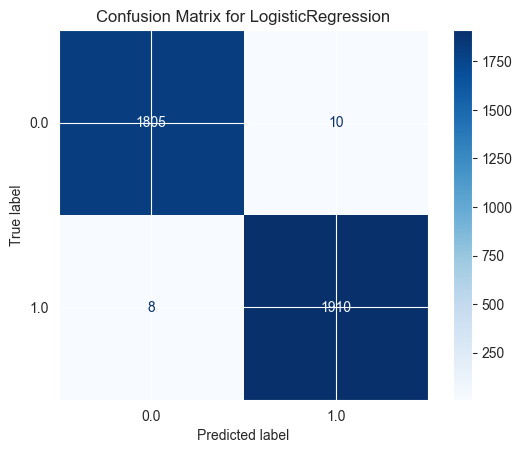

Метрики для модели SVC:
  Precision: 0.9948
  Recall: 0.9995
  F1-score: 0.9971
  Accuracy: 0.9971


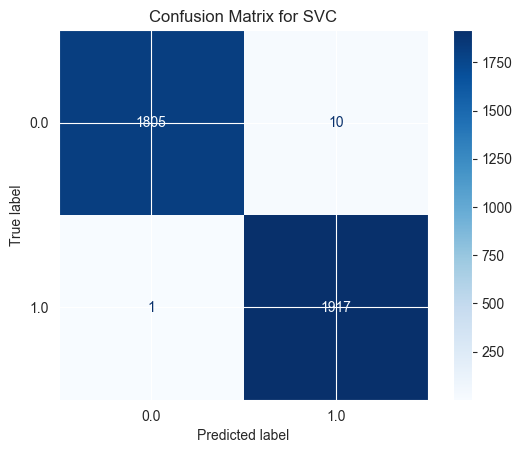

Метрики для модели DecisionTreeClassifier:
  Precision: 0.9859
  Recall: 0.9812
  F1-score: 0.9835
  Accuracy: 0.9831


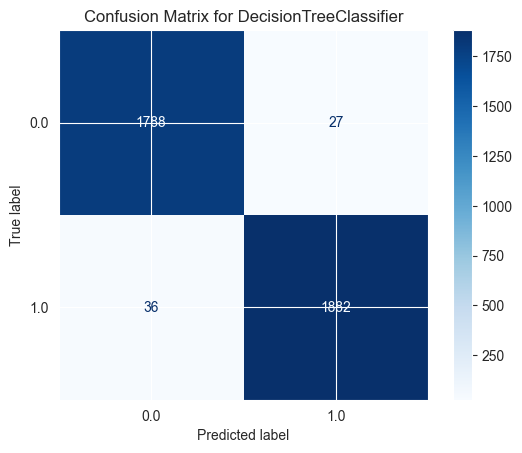

Метрики для модели RandomForestClassifier:
  Precision: 0.9870
  Recall: 0.9859
  F1-score: 0.9864
  Accuracy: 0.9861


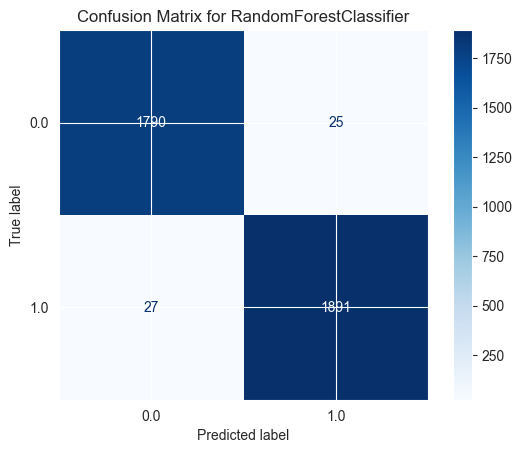

Метрики для модели CatBoostClassifier:
  Precision: 0.9943
  Recall: 0.9958
  F1-score: 0.9951
  Accuracy: 0.9949


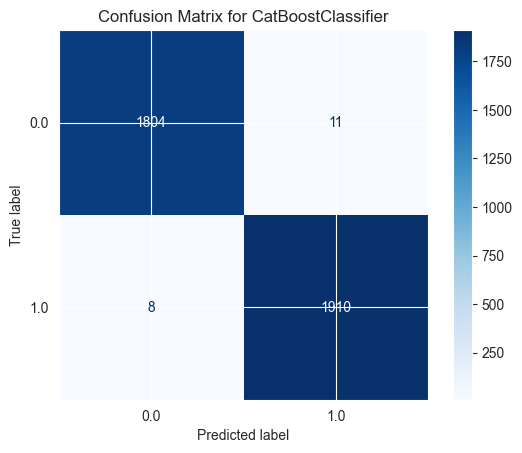


Рекомендации по выбору метрики:
Для модели LogisticRegression: Recall важнее Precision, так как требуется минимизация пропусков положительного класса.
Для модели SVC: Recall важнее Precision, так как требуется минимизация пропусков положительного класса.
Для модели DecisionTreeClassifier: F1-score может быть оптимальной, так как Precision выше Recall.
Для модели RandomForestClassifier: F1-score может быть оптимальной, так как Precision выше Recall.
Для модели CatBoostClassifier: Recall важнее Precision, так как требуется минимизация пропусков положительного класса.


In [55]:
from matplotlib import pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, ConfusionMatrixDisplay

# Список обученных моделей
print(f"Оптимизированные модели: {models}")

# Список для хранения метрик каждой модели
metrics_results = []

# Финальная проверка на тестовом наборе
for model in models:
    model_name = type(model).__name__

    # Обучение модели
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Вычисление метрик
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    metrics_results.append({
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Accuracy": accuracy
    })

    print(f"Метрики для модели {model_name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")

    # Построение confusion matrix
    disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues", values_format="d")
    disp.ax_.set_title(f"Confusion Matrix for {model_name}")
    plt.show()

# Выбор лучшей метрики
print("\nРекомендации по выбору метрики:")
for result in metrics_results:
    model = result["Model"]
    recall = result["Recall"]
    precision = result["Precision"]

    if recall < precision:
        recommendation = "F1-score может быть оптимальной, так как Precision выше Recall."
    elif recall > precision:
        recommendation = "Recall важнее Precision, так как требуется минимизация пропусков положительного класса."
    else:
        recommendation = "Можно использовать Accuracy или F1-score, так как Precision и Recall равны."

    print(f"Для модели {model}: {recommendation}")


In [54]:
print("Directed by Бутер Бродский")

Directed by Бутер Бродский
